# 00. Generate synthetic users dataset

Этот ноутбук формирует фиксированный synthetic user dataset для честного сравнения стратегий Pair Generator.

Добавлены более реалистичные `archetype8d` пользователи: dominant archetype + secondary archetype + preference intensity. Это позволяет моделировать как умеренные вкусы, так и пользователей с сильными/экстремальными EQ-предпочтениями, например basshead или extreme V-shape.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from personalization.synthetic_dataset import (
    TARGET_MODES,
    USER_ARCHETYPES_8D,
    generate_synthetic_users_dataset,
    dataset_metadata,
    save_synthetic_users_dataset,
)
from personalization.state import FEATURE_NAMES_8D
from personalization.plotting import plot_intensity_distribution

PROJECT_ROOT

WindowsPath('C:/Users/makcc/PycharmProjects/EarLoop/research/eq_personalization')

## Параметры генерации

Dataset содержит три режима:

- `random8d` — стресс-тест: target произвольный во всём 8D-пространстве;
- `semantic4d` — target генерируется в semantic 4D и отображается в weighted 8D;
- `archetype8d` — реалистичные пользователи как dominant/secondary audio archetypes + intensity.

In [3]:
N_PER_MODE = 100
SEED = 42
NOISE_STD = 0.05
IMPORTANCE_SIGMA = 0.35
TARGET_MAX_ABS = 2.0
ARCHETYPE_EXTREME_PROBABILITY = 0.30

DATASET_NAME = "synthetic_users_v2"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "datasets"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_PATH = OUTPUT_DIR / f"{DATASET_NAME}.csv"
METADATA_PATH = OUTPUT_DIR / f"{DATASET_NAME}_metadata.json"

## Генерация dataset

In [4]:
dataset = generate_synthetic_users_dataset(
    n_per_mode=N_PER_MODE,
    modes=TARGET_MODES,
    seed=SEED,
    noise_std=NOISE_STD,
    importance_sigma=IMPORTANCE_SIGMA,
    target_max_abs=TARGET_MAX_ABS,
    archetype_extreme_probability=ARCHETYPE_EXTREME_PROBABILITY,
)

dataset.head()

,user_id,target_mode,noise_std,z_sub_bass,z_bass,z_lowmid,z_warmth,z_presence,z_clarity,z_air,...,mix_warm,mix_bright,mix_v_shape,mix_mid_forward,mix_soft_dark,mix_detail_focused,mix_basshead,mix_extreme_vshape,mix_club_curve,mix_sparkle_lover
0,0,random8d,0.05,0.243774,-0.831987,0.600361,0.752452,-1.560828,-1.041744,0.102272,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,random8d,0.05,0.295001,-0.767106,0.702760,-0.039941,-0.147890,-0.544744,0.978033,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,random8d,0.05,-0.409794,-0.651018,0.492784,0.903178,-0.091158,-0.672125,-0.659585,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,random8d,0.05,0.543131,0.054063,0.231296,0.505031,-1.165725,-0.255737,-0.376298,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,random8d,0.05,0.568981,0.634678,-0.278980,-0.369881,0.686381,-0.153043,-1.020549,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Проверка состава dataset

In [5]:
dataset.groupby('target_mode').size().to_frame('n_users')

,n_users
target_mode,
archetype8d,100
random8d,100
semantic4d,100


## Распределение intensity / extreme archetypes

In [6]:
dataset.groupby(['target_mode', 'intensity_label']).size().to_frame('n_users')

n_users
target_mode intensity_label         
archetype8d extreme               16
            mild                  20
            moderate              28
            strong                36
random8d    random               100
semantic4d  semantic             100

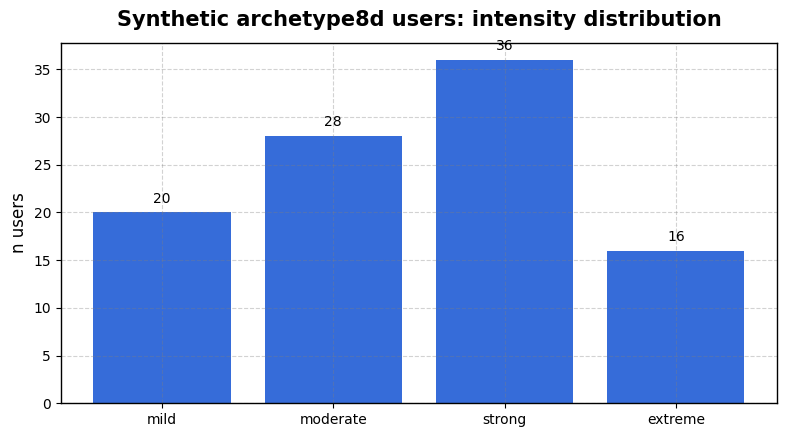

In [7]:
archetype_users = dataset[dataset['target_mode'] == 'archetype8d'].copy()

fig, ax = plot_intensity_distribution(
    archetype_users,
    title='Synthetic archetype8d users: intensity distribution',
)

In [8]:
archetype_users.groupby(['is_extreme_archetype', 'main_archetype']).size().to_frame('n_users').sort_index()

n_users
is_extreme_archetype main_archetype         
False                bass_lover            9
                     bright                2
                     detail_focused       11
                     mid_forward          13
                     neutral               6
                     soft_dark            11
                     v_shape               6
                     warm                  7
True                 basshead              8
                     club_curve            9
                     extreme_vshape        6
                     sparkle_lover        12

## Быстрая статистика target-векторов

In [9]:
target_columns = [f'z_{name}' for name in FEATURE_NAMES_8D]

dataset.groupby('target_mode')[target_columns].agg(['mean', 'std', 'min', 'max']).round(3)

z_sub_bass                      z_bass                       \
                  mean    std    min    max   mean    std    min    max   
target_mode                                                               
archetype8d      0.329  0.495 -0.346  1.576  0.453  0.550 -0.369  2.000   
random8d        -0.119  0.703 -1.686  1.840 -0.086  0.803 -2.000  1.848   
semantic4d      -0.003  0.583 -1.332  1.284  0.013  0.679 -1.582  1.572   

            z_lowmid         ... z_clarity         z_air                       \
                mean    std  ...       min    max   mean    std    min    max   
target_mode                  ...                                                
archetype8d    0.106  0.268  ...    -0.870  1.164  0.230  0.424 -0.489  1.367   
random8d      -0.134  0.852  ...    -2.000  2.000 -0.080  0.784 -1.961  1.861   
semantic4d     0.064  0.574  ...    -1.831  1.933 -0.016  0.663 -1.538  1.687   

            z_brightness                       
                    mean    std    min    max  
target_mode                                    
archetype8d        0.148  0.477 -0.929  1.587  
random8d          -0.000  0.824 -1.693  2.000  
semantic4d        -0.018  0.614 -1.350  1.557  

[3 rows x 32 columns]

## Архетипы realistic users

In [10]:
pd.DataFrame(USER_ARCHETYPES_8D, index=FEATURE_NAMES_8D).T.round(3)

,sub_bass,bass,lowmid,warmth,presence,clarity,air,brightness
neutral,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
bass_lover,0.8,1.0,0.3,0.1,-0.1,-0.2,-0.1,-0.2
warm,0.2,0.4,0.6,0.8,-0.2,-0.2,-0.1,-0.3
bright,-0.2,-0.1,-0.1,-0.2,0.2,0.5,0.7,0.8
v_shape,0.7,0.8,-0.2,-0.2,-0.2,0.2,0.5,0.4
mid_forward,-0.2,-0.1,0.3,0.2,0.8,0.4,-0.1,-0.1
soft_dark,0.2,0.3,0.4,0.6,-0.4,-0.5,-0.4,-0.7
detail_focused,-0.1,-0.1,-0.2,-0.1,0.3,0.8,0.6,0.5
basshead,1.2,1.4,0.4,0.2,-0.3,-0.4,-0.3,-0.4
extreme_vshape,1.0,1.2,-0.4,-0.4,-0.3,0.3,0.8,0.8


## Сохранение dataset

In [11]:
metadata = dataset_metadata(
    dataset_name=DATASET_NAME,
    n_per_mode=N_PER_MODE,
    seed=SEED,
    noise_std=NOISE_STD,
    importance_sigma=IMPORTANCE_SIGMA,
    target_max_abs=TARGET_MAX_ABS,
    archetype_extreme_probability=ARCHETYPE_EXTREME_PROBABILITY,
)
metadata['n_users_total'] = int(len(dataset))

save_synthetic_users_dataset(
    dataset=dataset,
    dataset_path=DATASET_PATH,
    metadata_path=METADATA_PATH,
    metadata=metadata,
)

print('Saved dataset:', DATASET_PATH)
print('Saved metadata:', METADATA_PATH)

Saved dataset: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\datasets\synthetic_users_v2.csv
Saved metadata: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\datasets\synthetic_users_v2_metadata.json


## Вывод

Создан фиксированный synthetic user dataset. Каждый пользователь имеет скрытый `z_target`, индивидуальный `feature_importance`, уровень шума выбора и режим генерации target.

Режим `archetype8d` теперь моделирует более реалистичных пользователей: target строится из dominant/secondary audio archetypes и умножается на `intensity_value`. Это позволяет тестировать не только умеренные настройки, но и сильные/экстремальные предпочтения, например basshead или extreme V-shape.